In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Mini_GWAS_RSV"
data_path = os.path.join(project_path, "data")
results_path = os.path.join(project_path, "results")

os.makedirs(data_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

print("Project folders ready.")

Project folders ready.


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_individuals = 500
n_snps = 100

genotypes = np.random.choice([0,1,2], size=(n_individuals, n_snps), p=[0.49,0.42,0.09])

true_betas = np.zeros(n_snps)
true_betas[:5] = [2.5, 3.0, -2.8, 2.2, 3.5]

linear_risk = np.dot(genotypes, true_betas)
prob = 1 / (1 + np.exp(-linear_risk))

phenotype = np.random.binomial(1, prob)

geno_df = pd.DataFrame(genotypes, columns=[f"SNP_{i}" for i in range(n_snps)])
geno_df["Phenotype"] = phenotype

geno_df.to_csv(os.path.join(data_path, "simulated_gwas_data.csv"), index=False)

print("Simulated dataset saved in Drive.")

Simulated dataset saved in Drive.


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

data = pd.read_csv(os.path.join(data_path, "simulated_gwas_data.csv"))

X = data.drop(columns=["Phenotype"])
y = data["Phenotype"]

p_values = []
betas = []

for snp in X.columns:
    X_snp = sm.add_constant(X[[snp]])
    model = sm.Logit(y, X_snp)

    try:
        result = model.fit(disp=0)
        betas.append(result.params[1])
        p_values.append(result.pvalues[1])
    except:
        betas.append(0)
        p_values.append(1)

results = pd.DataFrame({
    "SNP": X.columns,
    "Beta": betas,
    "P_value": p_values
})

results["FDR"] = multipletests(results["P_value"], method='fdr_bh')[1]
results["-log10(P)"] = -np.log10(results["P_value"])

results.to_csv(os.path.join(results_path, "gwas_results.csv"), index=False)

print("GWAS results saved in Drive.")

/tmp/ipykernel_578/2140428331.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas.append(result.params[1])
/tmp/ipykernel_578/2140428331.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_values.append(result.pvalues[1])
/tmp/ipykernel_578/2140428331.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas.append(result.params[1])
/tmp/ipykernel_578/2140428331.py:19: FutureWarning: Series.__getitem__ treating keys as po

GWAS results saved in Drive.


/tmp/ipykernel_578/2140428331.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  betas.append(result.params[1])
/tmp/ipykernel_578/2140428331.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_values.append(result.pvalues[1])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
plt.scatter(range(len(results)), results["-log10(P)"])

bonf_threshold = 0.05 / n_snps
plt.axhline(-np.log10(bonf_threshold), linestyle='--')

plt.xlabel("SNP Index")
plt.ylabel("-log10(P-value)")
plt.title("Mini GWAS Manhattan Plot")

plt.savefig(os.path.join(results_path, "manhattan_plot.png"))

plt.close()

print("Manhattan plot saved in Drive.")

Manhattan plot saved in Drive.


In [ ]:
plt.show()

In [ ]:
results.sort_values("P_value").head(10)

,SNP,Beta,P_value,FDR,-log10(P)
2,SNP_2,-1.266576,8.432110e-12,8.432110e-10,11.074064
4,SNP_4,1.750122,3.853138e-09,1.926569e-07,8.414185
1,SNP_1,1.766718,2.461196e-08,8.203985e-07,7.608854
0,SNP_0,1.142914,3.303441e-06,8.258602e-05,5.481033
3,SNP_3,1.151585,5.268375e-06,1.053675e-04,5.278323
87,SNP_87,0.542402,9.411935e-03,1.568656e-01,2.026321
17,SNP_17,-0.441286,1.102826e-02,1.575465e-01,1.957493
16,SNP_16,-0.422454,2.453982e-02,3.067477e-01,1.610129
98,SNP_98,-0.366096,4.548602e-02,4.678929e-01,1.342122
31,SNP_31,0.399709,4.678929e-02,4.678929e-01,1.329854


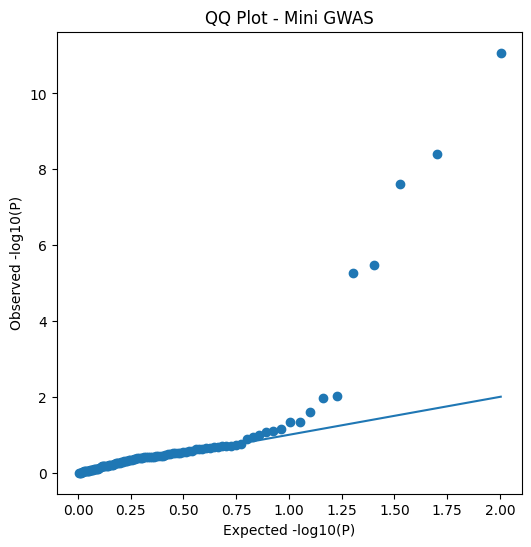

QQ plot saved to Drive.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Sort observed p-values
observed = np.sort(results["P_value"])

# Expected p-values under null hypothesis
expected = np.arange(1, len(observed)+1) / (len(observed)+1)

# Convert to -log10 scale
observed_log = -np.log10(observed)
expected_log = -np.log10(expected)

# Create plot
plt.figure(figsize=(6,6))
plt.scatter(expected_log, observed_log)
plt.plot([0, max(expected_log)], [0, max(expected_log)])  # diagonal reference line

plt.xlabel("Expected -log10(P)")
plt.ylabel("Observed -log10(P)")
plt.title("QQ Plot - Mini GWAS")

# Save to Drive
plt.savefig(os.path.join(results_path, "qq_plot.png"))
plt.show()
plt.close()

print("QQ plot saved to Drive.")